In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoProcessor, LlavaForConditionalGeneration
from PIL import Image
import time
import threading
import requests

/home/eros483/miniconda3/envs/deepLure/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "llava-hf/llava-1.5-7b-hf"
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"

In [3]:
timestamps = []
vram_usage = []
start_time = None
monitoring = False
markers = []

In [4]:
def monitor_vram(interval=0.05):
    """Background thread to monitor vRAM"""
    global monitoring, timestamps, vram_usage, start_time
    while monitoring:
        if torch.cuda.is_available():
            current_time = (time.time() - start_time) * 1000
            vram_mb = torch.cuda.memory_allocated() / (1024 ** 2)
            timestamps.append(current_time)
            vram_usage.append(vram_mb)
        time.sleep(interval)

def add_marker(label):
    """Add a marker at current time"""
    if torch.cuda.is_available():
        current_time = (time.time() - start_time) * 1000
        current_vram = torch.cuda.memory_allocated() / (1024 ** 2)
        markers.append((current_time, current_vram, label))
        print(f"[{current_time:.1f}ms] {label}: {current_vram:.1f} MB")

In [5]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. GPU required for profiling.")

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

monitoring = True
start_time = time.time()
monitor_thread = threading.Thread(target=monitor_vram, daemon=True)
monitor_thread.start()

time.sleep(0.1)
add_marker("Start")

[100.8ms] Start: 0.0 MB


- **Loading Processor**

In [6]:
processor = AutoProcessor.from_pretrained(model_id)
add_marker("Processor Loaded")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[4245.1ms] Processor Loaded: 0.0 MB


- **Loading Model**

In [7]:
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
add_marker("Model Loaded")

time.sleep(0.2)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  4.11it/s]


[6441.4ms] Model Loaded: 13472.4 MB


- **Loading image**

In [8]:
image = Image.open(requests.get(image_url, stream=True).raw)
add_marker("Image Loaded")

[6997.6ms] Image Loaded: 13472.4 MB


- **Preparing embeds for text and image**

In [9]:
prompt = "USER: <image>\nWhat is in this image?\nASSISTANT:"
inputs = processor(text=prompt, images=image, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}
add_marker("Inputs Prepared")

[7007.7ms] Inputs Prepared: 13473.7 MB


- **Model Inference**

In [10]:
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=50)
add_marker("Inference Complete")

[8709.7ms] Inference Complete: 13482.9 MB


- **Decode Step**

In [11]:
generated_text = processor.decode(outputs[0], skip_special_tokens=True)
print(f"\nGenerated: {generated_text[:100]}...")

time.sleep(0.2)


Generated: USER:  
What is in this image?
ASSISTANT: The image features a vintage, light blue Volkswagen Beetle...


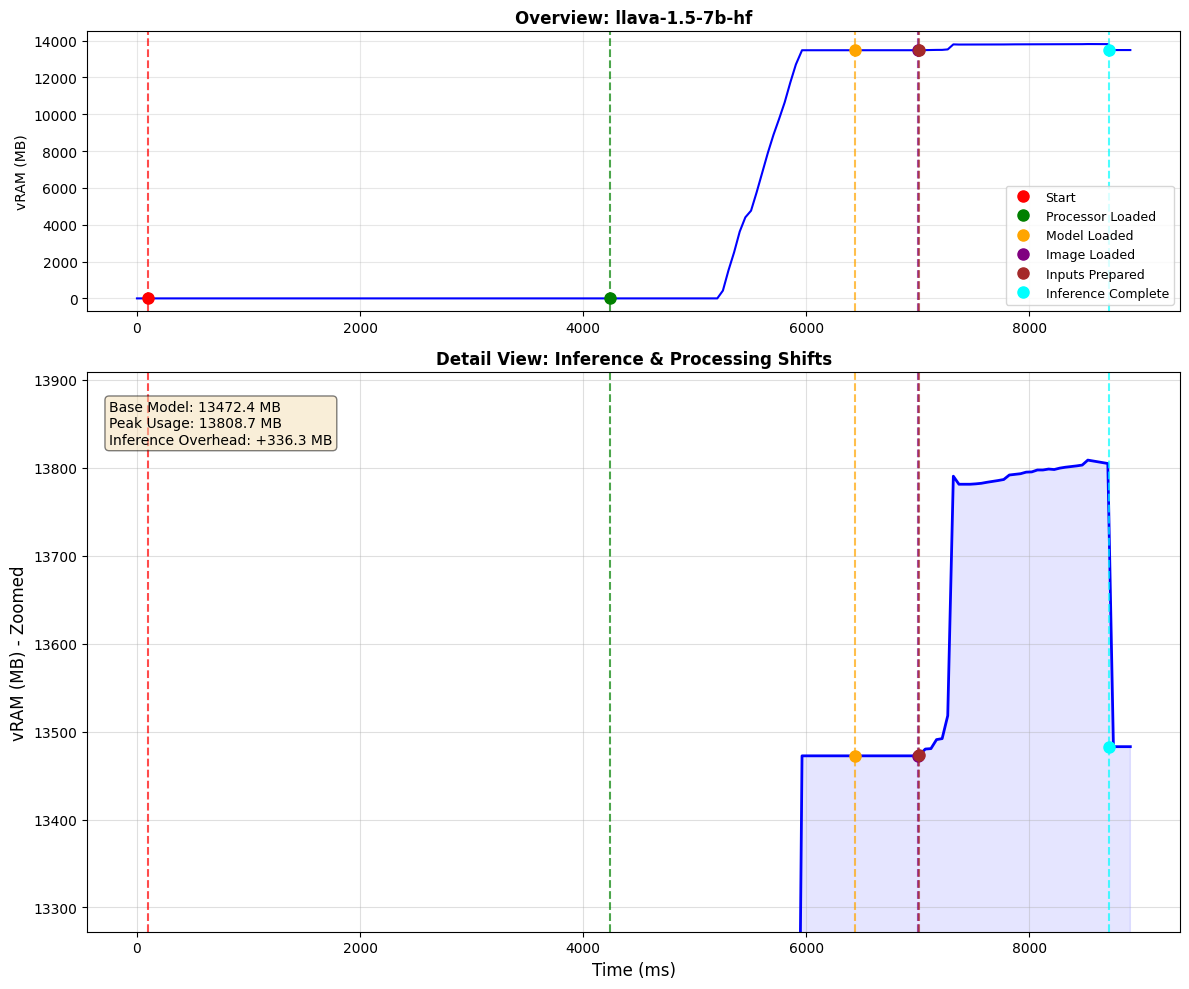

In [12]:
model_loaded_val = next((v for t, v, l in markers if l == "Model Loaded"), 0)
max_val = max(vram_usage)

y_zoom_min = model_loaded_val - 200
y_zoom_max = max_val + 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 2]})

ax1.plot(timestamps, vram_usage, 'b-', linewidth=1.5)
ax1.set_title(f'Overview: {model_id.split("/")[-1]}', fontsize=12, fontweight='bold')
ax1.set_ylabel('vRAM (MB)')
ax1.grid(True, alpha=0.3)

ax2.plot(timestamps, vram_usage, 'b-', linewidth=2)
ax2.fill_between(timestamps, vram_usage, alpha=0.1, color='blue')

ax2.set_ylim(y_zoom_min, y_zoom_max)
ax2.set_title('Detail View: Inference & Processing Shifts', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('vRAM (MB) - Zoomed', fontsize=12)
ax2.grid(True, alpha=0.4, which='both')

colors = ['red', 'green', 'orange', 'purple', 'brown', 'cyan']
for ax in [ax1, ax2]:
    for i, (t, vram, label) in enumerate(markers):
        color = colors[i % len(colors)]
        ax.axvline(x=t, color=color, linestyle='--', alpha=0.7)
        if ax == ax1 or (y_zoom_min <= vram <= y_zoom_max):
            ax.plot(t, vram, 'o', color=color, markersize=8, label=label if ax == ax1 else "")

ax1.legend(loc='lower right', fontsize=9)

inference_delta = max_val - model_loaded_val
stats_text = (f"Base Model: {model_loaded_val:.1f} MB\n"
              f"Peak Usage: {max_val:.1f} MB\n"
              f"Inference Overhead: +{inference_delta:.1f} MB")

ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round',
        facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()

plt.savefig('../metrics/vram_profile_inference.png')

plt.show()